In [23]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

In [25]:
def gillespie_oosawa(M0, P0, k_n, k_plus, n, t_max):
    """
    Gillespie simulation for Oosawa model
    
    Parameters:
        M0 : initial monomers
        P0 : initial polymers
        k_n : nucleation rate
        k_plus : elongation rate
        n : nucleus size
        t_max : simulation time
    """
    

    t = 0.0
    M = M0
    P = P0
    

    times = [t]
    M_vals = [M]
    P_vals = [P]
    
    while t < t_max:
        
        # Propensities
        if M >= n:
            a1 = k_n * comb(M, n)
        else:
            a1 = 0.0
            
        a2 = k_plus * M * P
        
        a0 = a1 + a2
        
        if a0 == 0:
            break
        
        # Random numbers
        r1, r2 = np.random.rand(2)
        
        # Time step
        tau = (1.0 / a0) * np.log(1.0 / r1)
        t += tau
        
        # Reaction selection
        if r2 * a0 < a1:
            # Nucleation
            M -= n
            P += 1
        else:
            # Elongation
            M -= 1
        
        # Store
        times.append(t)
        M_vals.append(M)
        P_vals.append(P)
    
    return np.array(times), np.array(M_vals), np.array(P_vals)

In [27]:
# ---- Example ----
M0 = 100
P0 = 0
k_n = 1e-5
k_plus = 1e-2
n = 2
t_max = 100

times, M_vals, P_vals = gillespie_oosawa(M0, P0, k_n, k_plus, n, t_max)

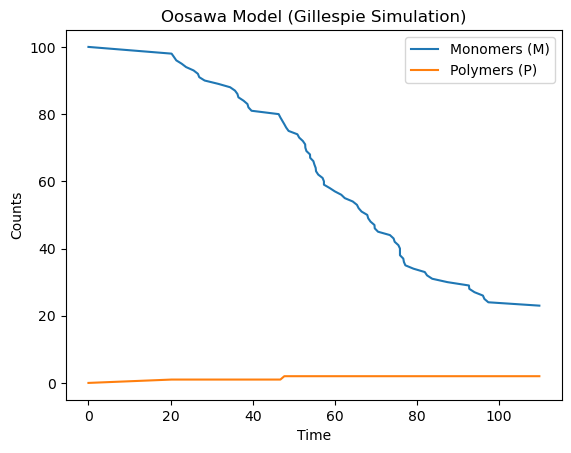

In [29]:
plt.figure()
plt.plot(times, M_vals, label="Monomers (M)")
plt.plot(times, P_vals, label="Polymers (P)")
plt.xlabel("Time")
plt.ylabel("Counts")
plt.legend()
plt.title("Oosawa Model (Gillespie Simulation)")
plt.show()